In [1]:
import numpy as np
from scipy.stats import norm

In [4]:
S0 = 1.15
K = 1.05
sigma = 0.1
notional = 50e6

In [8]:
def call_price(S, K, sigma, T):
    if T == 0:
        return max(S-K, 0)
    d1 = (np.log(S/K) + 0.5*sigma**2*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*norm.cdf(d2)

In [11]:
EE = []
for t in range(6):
    EE.append(notional * call_price(S0, K, sigma, t))

[4999999.9999999935,
 5541624.994005295,
 6219131.698819624,
 6805805.748805915,
 7324755.321226329,
 7793834.02326807]

In [12]:
LGD = 0.6
pd = 0.0408

CVA = 0
for i in range(1,6):
    avg_EE = 0.5*(EE[i-1] + EE[i])
    CVA += LGD * avg_EE * pd

790415.9872795444

In [6]:
sigma1 = 0.11
EE1 = []
for t in range(6):
    EE1.append(notional * call_price(S0, K, sigma1, t))

[4999999.9999999935,
 5691920.513054355,
 6475271.930553372,
 7139339.696929858,
 7721599.654132794,
 8245318.364150267]

In [13]:
CVA1 = 0
for i in range(1,6):
    avg_EE1 = 0.5*(EE1[i-1] + EE1[i])
    CVA1 += LGD * avg_EE1 * pd

823771.3631107302

In [14]:
S1 = 1.16
EE2 = []
for t in range(6):
    EE2.append(notional * call_price(S1, K, sigma, t))

[5499999.9999999935,
 5962630.508755745,
 6604990.768817248,
 7174740.630036686,
 7683684.359583331,
 8146189.0544122225]

In [15]:
CVA2 = 0
for i in range(1,6):
    CVA2 += LGD * 0.5*(EE2[i-1]+EE2[i]) * pd

838418.9666468904

In [2]:
import numpy as np

# Parameters
T_max = 5
n_paths = 1_000_000

np.random.seed(42)

EE = []

for t in range(T_max + 1):
    if t == 0:
        # deterministic at time 0
        EE_t = notional * max(S0 - K, 0)
    else:
        Z = np.random.randn(n_paths)
        Xt = S0 * np.exp(-0.5 * sigma**2 * t + sigma * np.sqrt(t) * Z)
        payoff = notional * np.maximum(Xt - K, 0)
        EE_t = payoff.mean()
    EE.append(EE_t)

EE

[4999999.9999999935,
 5534066.369155618,
 6222255.561120302,
 6807126.035673907,
 7324267.059253727,
 7797919.262747547]

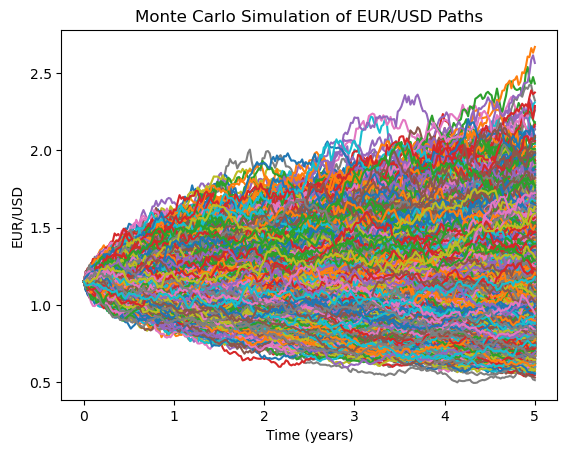

In [8]:
T = 5
n_paths = 10000
n_steps = 250
dt = T / n_steps

np.random.seed(1)
time = np.linspace(0, T, n_steps + 1)

paths = np.zeros((n_paths, n_steps + 1))
paths[:, 0] = S0

for t in range(1, n_steps + 1):
    Z = np.random.randn(n_paths)
    paths[:, t] = paths[:, t-1] * np.exp(
        -0.5 * sigma**2 * dt + sigma * np.sqrt(dt) * Z)

plt.figure()
for i in range(n_paths):
    plt.plot(time, paths[i])

plt.xlabel("Time (years)")
plt.ylabel("EUR/USD")
plt.title("Monte Carlo Simulation of EUR/USD Paths")
plt.show()